# Part 3 - Application: mean-variance frontier on ETF returns

Single-period long-only Markowitz on 11 ETFs (see `python/data/metadata.json`).

**Not investment advice.** Daily returns; sample estimates of mu and Sigma.

In [24]:
%matplotlib inline

import json
import sys
from pathlib import Path

import polars as pl
from IPython.display import display, Markdown

REPO = Path.cwd().resolve()
if not (REPO / "scripts" / "run_all.py").exists():
    REPO = REPO.parents[1]
sys.path.insert(0, str(REPO / "python" / "src"))

from portfolio_linalg.config import load_config
from portfolio_linalg.covariance import build_covariance
from portfolio_linalg.fetch_data import fetch_and_cache, load_returns
from portfolio_linalg.frontier import compute_frontier, min_variance_portfolio
from portfolio_linalg.interpret import (
    asset_summary_table,
    frontier_summary_table,
    min_variance_weights_table,
)
from portfolio_linalg.plots import all_figures, generate_all

## 1. Data

In [25]:
cfg = load_config(REPO / "python" / "config.yaml")
cache = cfg.data_dir / "returns.parquet"

if cache.exists():
    returns = load_returns(cfg)
    print(f"Loaded cached returns: {cache}")
else:
    print("No cache — fetching via httpx (Yahoo chart API)...")
    returns = fetch_and_cache(cfg)

meta = json.loads((cfg.data_dir / "metadata.json").read_text(encoding="utf-8"))
display(Markdown(f"**{meta['n_obs']}** daily rows, **{meta['n_assets']}** assets, "
                 f"{meta['date_min']} to {meta['date_max']} ({meta['source']})."))

Loaded cached returns: C:\Users\tclay\Documents\Projects\math5110-portfolio-linalg\python\data\returns.parquet


**500** daily rows, **11** assets, 2024-05-30 to 2026-05-29 (yahoo).

## 2. Covariance and PSD check (`np.cov`, `np.linalg.eigh`)

In [26]:
cov = build_covariance(returns)
display(Markdown(
    f"- PSD (min eigenvalue >= -1e-8): **{cov.is_psd}** (min λ = {cov.min_eigenvalue:.2e})\n"
    f"- Condition number κ(Σ) ≈ **{cov.condition_number:.1f}**"
))

- PSD (min eigenvalue >= -1e-8): **True** (min λ = 9.92e-07)
- Condition number κ(Σ) ≈ **939.9**

## 3. Single-asset comparison (sample daily mu / sigma)

In [27]:
display(asset_summary_table(cov))

ticker,mu_daily,sigma_daily,mu_over_sigma
str,f64,f64,f64
"""GLD""",0.001415,0.014332,0.098741
"""EEM""",0.001049,0.012416,0.084488
"""XLK""",0.001333,0.016413,0.081212
"""QQQ""",0.001073,0.013438,0.079878
"""SPY""",0.000795,0.010528,0.075503
…,…,…,…
"""EFA""",0.000585,0.010472,0.055829
"""XLF""",0.000519,0.011082,0.046799
"""XLE""",0.000533,0.0145,0.036752


## 4. CVXPY efficient frontier

In [28]:
frontier = compute_frontier(cov, cfg)
mvp = min_variance_portfolio(cov, cfg)
fs = frontier_summary_table(cov, frontier)

display(Markdown("### Min-variance long-only portfolio"))
display(min_variance_weights_table(cov, cfg))
display(Markdown(
    f"Daily mu = **{mvp['mu']:.6f}**, sigma = **{mvp['sigma']:.6f}**"
))

display(Markdown("### Frontier endpoints (daily)"))
display(pl.DataFrame({
    "point": ["low return (≈ min-var)", "high return", "best mu/sigma on frontier"],
    "mu": [fs.mu_low, fs.mu_high, fs.best_mu],
    "sigma": [fs.sigma_low, fs.sigma_high, fs.best_sigma],
}))

display(Markdown("### Weights at high-return frontier point"))
display(fs.high_return_weights)

### Min-variance long-only portfolio

ticker,weight
str,f64
"""AGG""",0.928062
"""XLE""",0.052138
"""XLF""",0.01756
"""GLD""",0.002239


Daily mu = **0.000099**, sigma = **0.002905**

### Frontier endpoints (daily)

point,mu,sigma
str,f64,f64
"""low return (≈ min-var)""",0.000099,0.002905
"""high return""",0.001415,0.014333
"""best mu/sigma on frontier""",0.001204,0.009986


### Weights at high-return frontier point

ticker,weight
str,f64
"""GLD""",1.000032


## 5. Figures (saved to `python/figures/` and shown inline)

Saved:
  C:\Users\tclay\Documents\Projects\math5110-portfolio-linalg\python\figures\efficient_frontier.png
  C:\Users\tclay\Documents\Projects\math5110-portfolio-linalg\python\figures\eigenvalues.png
  C:\Users\tclay\Documents\Projects\math5110-portfolio-linalg\python\figures\correlation_heatmap.png
  C:\Users\tclay\Documents\Projects\math5110-portfolio-linalg\python\figures\weights_vs_return.png


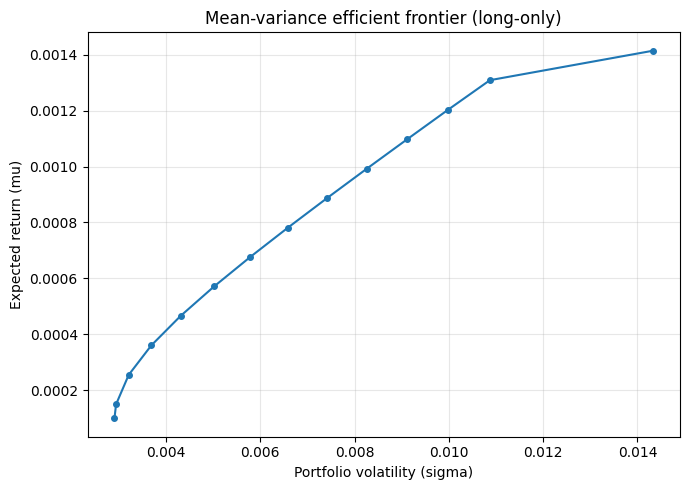

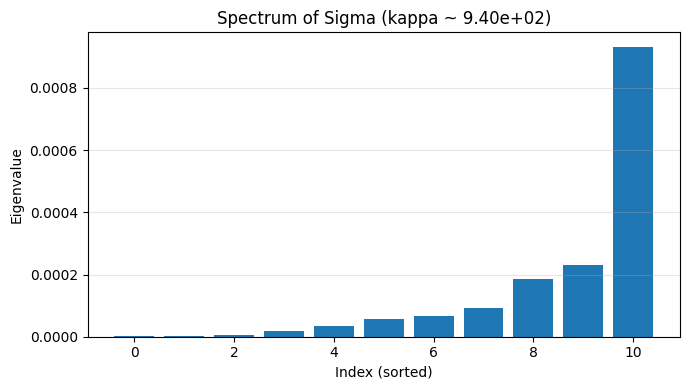

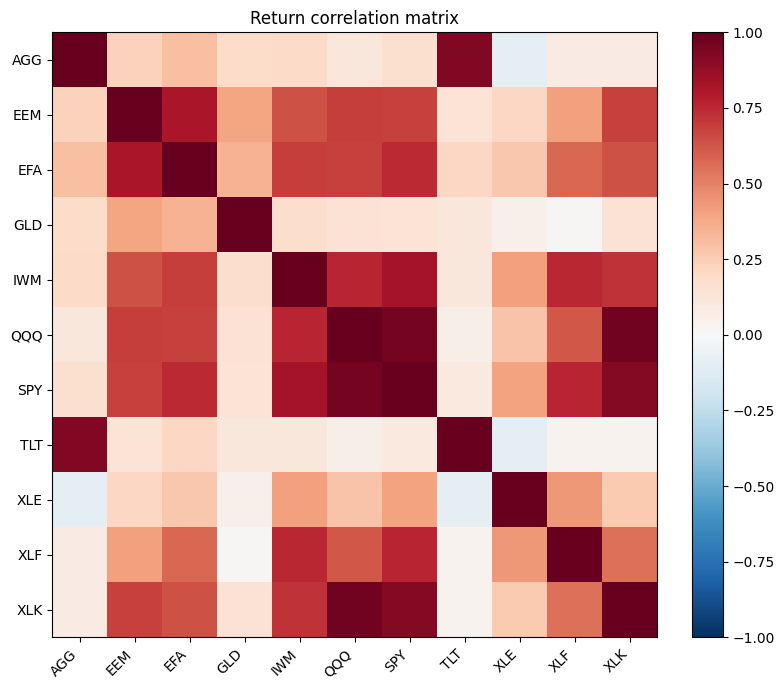

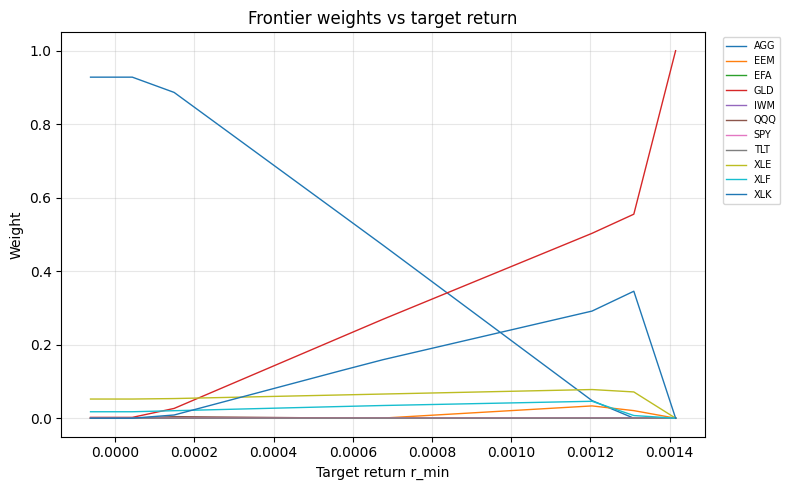

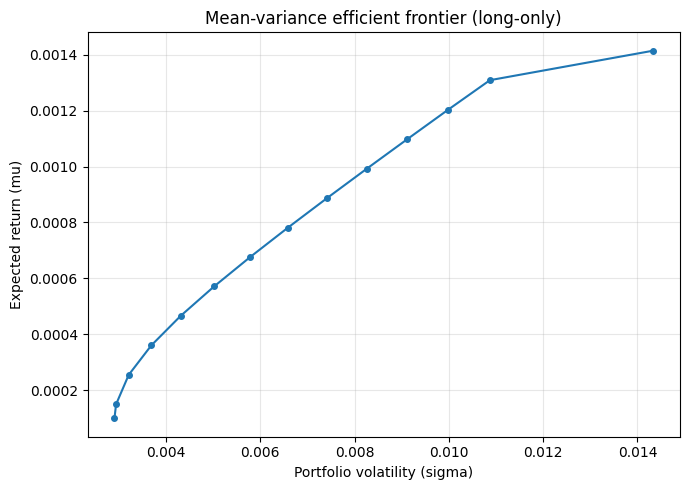

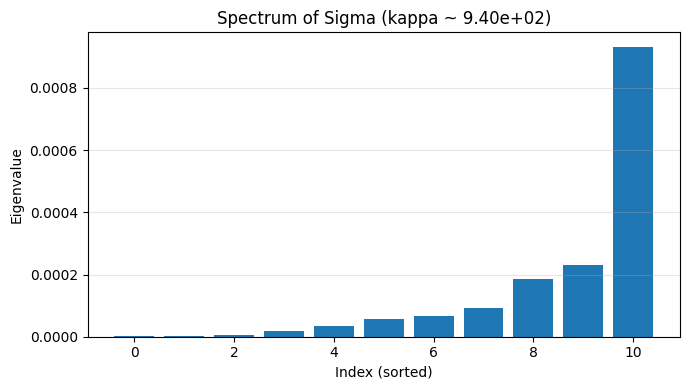

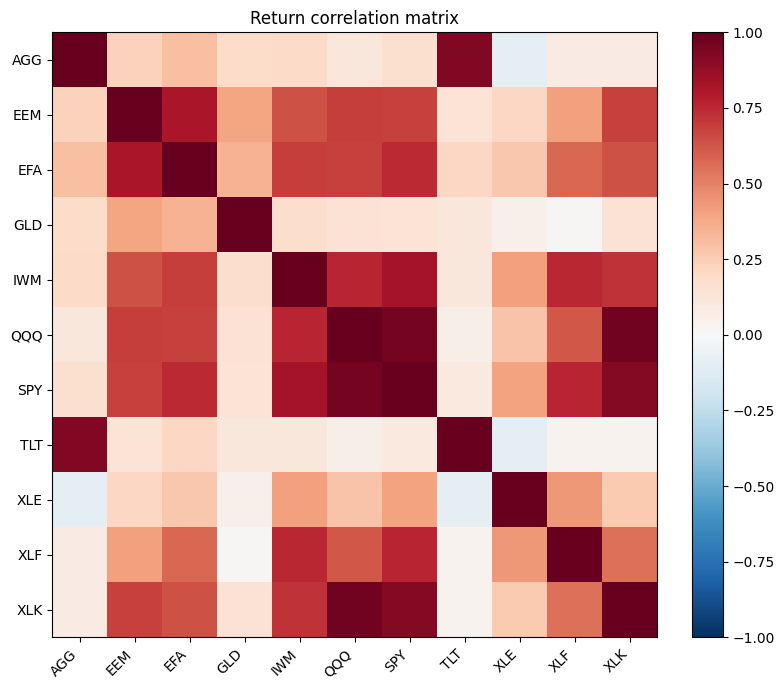

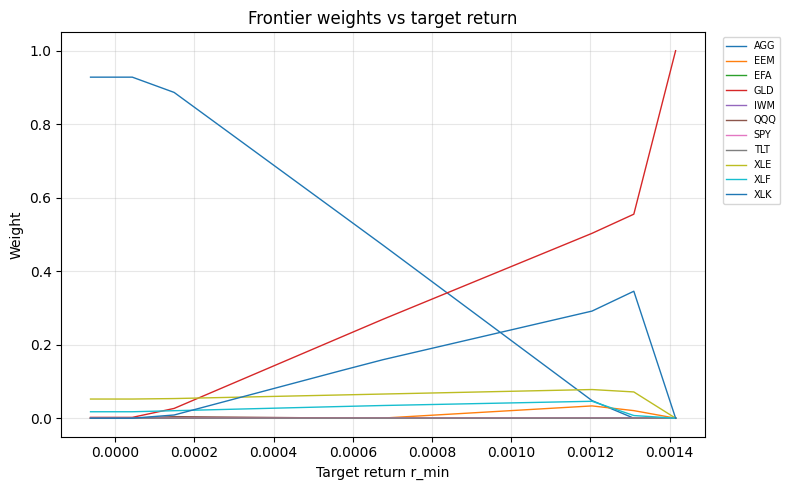

In [29]:
paths = generate_all(cov, frontier, cfg.figures_dir)
print("Saved:")
for p in paths:
    print(f"  {p}")

for fig in all_figures(cov, frontier):
    display(fig)

## 6. Interpretation

- **Minimum risk** in this sample is achieved mostly with low-volatility bond exposure (see min-variance weights), not the highest single-asset return.
- **Highest target return** on the frontier often concentrates in the best sample mean asset (frequently GLD in our window) - a known quirk of sample-based Markowitz.
- The frontier curve trades **daily** expected return for **daily** volatility; eigenvalues and correlations explain why diversification is limited across equity ETFs.
- Formal PSD / variance facts are in `lean/`; the QP solver is not verified in Lean.

## 7. Annualized figures (252 trading days)

Daily mu and sigma are scaled for readability:

- **mu_annual** ≈ mu_daily × 252  
- **sigma_annual** ≈ sigma_daily × √252  

This is a simple i.i.d. scaling convention for the report, not a forecast.

Using **252** trading days per year.

### Single assets (annualized)

ticker,mu_daily,sigma_daily,mu_over_sigma,mu_annual,sigma_annual,mu_over_sigma_annual
str,f64,f64,f64,f64,f64,f64
"""GLD""",0.001415,0.014332,0.098741,0.35663,0.227519,1.56747
"""EEM""",0.001049,0.012416,0.084488,0.264355,0.197103,1.341202
"""XLK""",0.001333,0.016413,0.081212,0.335898,0.260547,1.289202
"""QQQ""",0.001073,0.013438,0.079878,0.270489,0.213315,1.268027
"""SPY""",0.000795,0.010528,0.075503,0.200307,0.167121,1.198573
…,…,…,…,…,…,…
"""EFA""",0.000585,0.010472,0.055829,0.147323,0.16623,0.886259
"""XLF""",0.000519,0.011082,0.046799,0.130693,0.175919,0.742916
"""XLE""",0.000533,0.0145,0.036752,0.134293,0.230181,0.583424


### Min-variance portfolio (annualized)

- mu_annual = **2.48%**
- sigma_annual = **4.61%**
- (daily: mu = 0.000099, sigma = 0.002905)

### Frontier points (annualized)

mu,sigma,r_min_target,mu_annual,sigma_annual
f64,f64,f64,f64,f64
0.000099,0.002905,-0.000062,0.02483,0.046116
0.000099,0.002905,0.000043,0.02483,0.046116
0.000149,0.002939,0.000149,0.037495,0.046661
0.000254,0.003208,0.000254,0.06409,0.05092
0.00036,0.003687,0.00036,0.090684,0.058537
…,…,…,…,…
0.000993,0.008262,0.000993,0.250252,0.131163
0.001099,0.00912,0.001099,0.276846,0.144773
0.001204,0.009986,0.001204,0.303441,0.15853


### Efficient frontier (annualized axes)

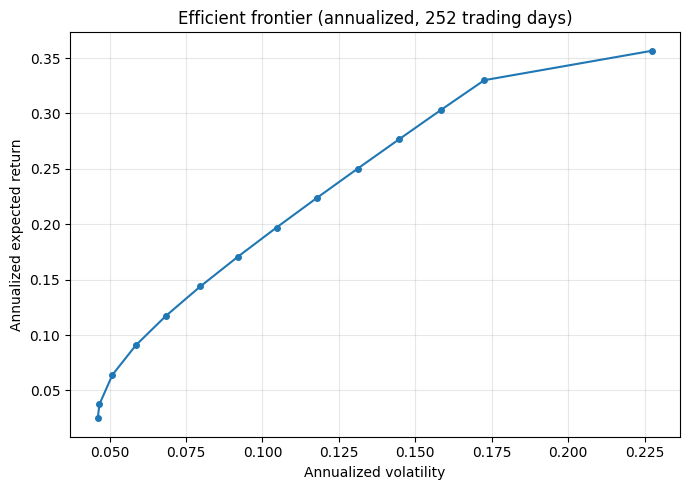

In [30]:
import importlib
import matplotlib.pyplot as plt

import portfolio_linalg.interpret as interpret
importlib.reload(interpret)  # pick up edits without restarting kernel

from portfolio_linalg.interpret import (
    TRADING_DAYS_PER_YEAR,
    asset_summary_annualized,
    frontier_points_annualized,
    min_variance_annualized,
)
import portfolio_linalg.plots as plots

importlib.reload(plots)
from portfolio_linalg.plots import figure_efficient_frontier

display(Markdown(f"Using **{TRADING_DAYS_PER_YEAR}** trading days per year."))

display(Markdown("### Single assets (annualized)"))
display(asset_summary_annualized(cov))

mvp_ann = min_variance_annualized(cov, cfg)
display(Markdown(
    f"### Min-variance portfolio (annualized)\n\n"
    f"- mu_annual = **{100 * mvp_ann['mu_annual']:.2f}%**\n"
    f"- sigma_annual = **{100 * mvp_ann['sigma_annual']:.2f}%**\n"
    f"- (daily: mu = {mvp_ann['mu_daily']:.6f}, sigma = {mvp_ann['sigma_daily']:.6f})"
))

display(Markdown("### Frontier points (annualized)"))
display(frontier_points_annualized(frontier))

display(Markdown("### Efficient frontier (annualized axes)"))
fig_ann = figure_efficient_frontier(frontier, annualized=True)
display(fig_ann)
plt.close(fig_ann)

## 8. Covariance estimators, spectrum, and KKT check

- Compare sample vs Ledoit-Wolf vs rank-k / eigen-floor on the same mu.
- Largest eigenmodes (eigenportfolio loadings) and variance explained.
- On SPY/AGG/GLD: CVXPY vs SciPy weights; stationarity residuals from dual variables.

KKT stationarity (long-only Markowitz):

$$\Sigma x - \lambda \mathbf{1} - \nu \mu - \pi = 0,\quad \pi \ge 0,\; x \ge 0,\; \pi_i x_i = 0.$$


In [ ]:
from portfolio_linalg.comparison import build_comparison_bundle
from portfolio_linalg.interpret import (
    comparison_summary_table,
    kkt_summary_table,
    kkt_stationarity_table,
)
from portfolio_linalg.kkt import format_kkt_report
from portfolio_linalg.plots import (
    figure_frontier_compare,
    figure_variance_explained,
    figure_eigenportfolios,
    generate_comparison_figures,
)

bundle = build_comparison_bundle(returns, cfg, cfg.comparison)
display(Markdown(
    f"Ledoit-Wolf shrinkage = **{bundle.lw_shrinkage:.4f}**; "
    f"kappa sample = {bundle.sample.condition_number:.0f} -> LW = {bundle.ledoit_wolf.condition_number:.0f}"
))
display(Markdown("### Min-variance by covariance estimator"))
display(comparison_summary_table(bundle, cfg))
display(Markdown("### KKT summary (3 assets)"))
display(kkt_summary_table(bundle))
display(kkt_stationarity_table(bundle))
for kkt in bundle.kkt_results:
    print(format_kkt_report(kkt, bundle.kkt_tickers))
    print()

for fig in (
    figure_frontier_compare(bundle),
    figure_variance_explained(bundle),
    figure_eigenportfolios(bundle.sample),
):
    display(fig)

comp_paths = generate_comparison_figures(bundle, cfg.figures_comparison_dir, solver=cfg.solver)
print("Saved comparison figures:")
for path in comp_paths:
    print(f"  {path}")
